In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# For countplot charts
count_palette = {0: 'steelblue', 1: 'darkorange'}

# For histplot charts  
hist_palette = {0: 'steelblue', 1: 'darkorange'}

# Load the dataset
df = pd.read_csv('Customer-Churn-Records.csv')

In [2]:
# Explore the dataset
print("Dataset shape:",  df.shape)
print("First few rows of the dataset:")
print(df.head())
print("Dataset information:")
print(df.info())
print("Dataset description:")
print(df.describe())

Dataset shape: (10000, 18)
First few rows of the dataset:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1    

In [3]:
# Check for missing values
print(df.isnull().sum())

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [4]:
# Check dataset balance of the target variable 'Exited'
print("Dataset balance of column 'Exited':")
df['Exited'].value_counts()

# Check the proportion of customers who churned vs those who did not
print("Proportion of customers who churned vs those who did not:")
df['Exited'].value_counts(normalize = True)

Dataset balance of column 'Exited':
Proportion of customers who churned vs those who did not:


Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

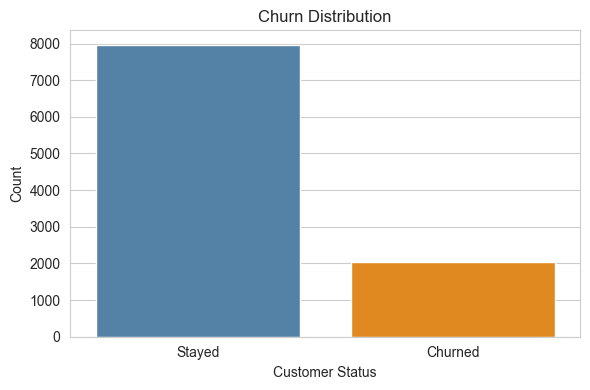

In [5]:
# Visualize the distribution of the target variable 'Exited'
# Churn distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', hue='Exited', data=df, palette=count_palette, legend=False)
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_distribution.png')
plt.show()

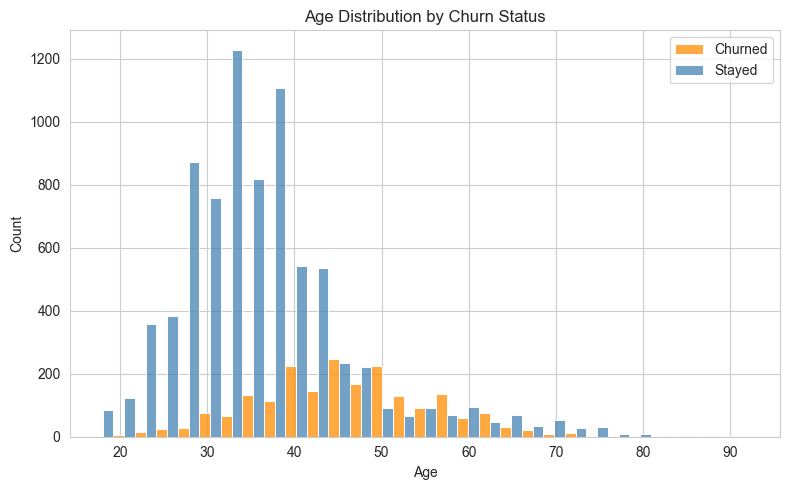

In [6]:
# Which factors are associated with customers leaving?
# The business logic: start with the features most likely to be strong predictors based on business intuition.
# 1. Age: Older customers may have different needs and may be more likely to churn if those needs are not met.

# Age distribution by churn status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Exited', bins=30,
             palette=hist_palette, multiple='dodge',
             hue_order=[0, 1])
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(labels=['Churned', 'Stayed'])
plt.tight_layout()
plt.savefig('churn_by_age.png')
plt.show()

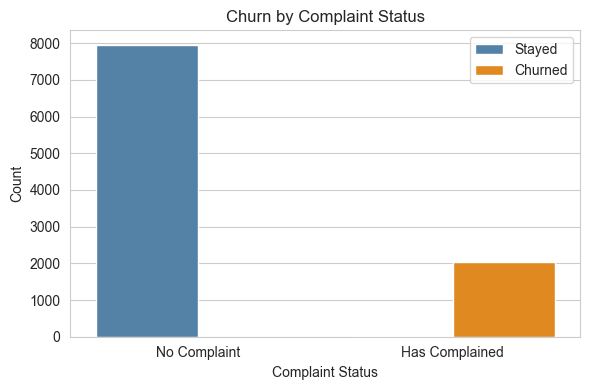

In [7]:
# The business logic: A customer who has complained is already signaling dissatisfaction.
# 2. Complaint status: Does complaining actually predict whether they leave?

# Churn rate by complaint status
plt.figure(figsize=(6, 4))
sns.countplot(x='Complain', hue='Exited', data=df, palette=count_palette)
plt.title('Churn by Complaint Status')
plt.xticks([0, 1], ['No Complaint', 'Has Complained'])
plt.xlabel('Complaint Status')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_complaint.png')
plt.show()

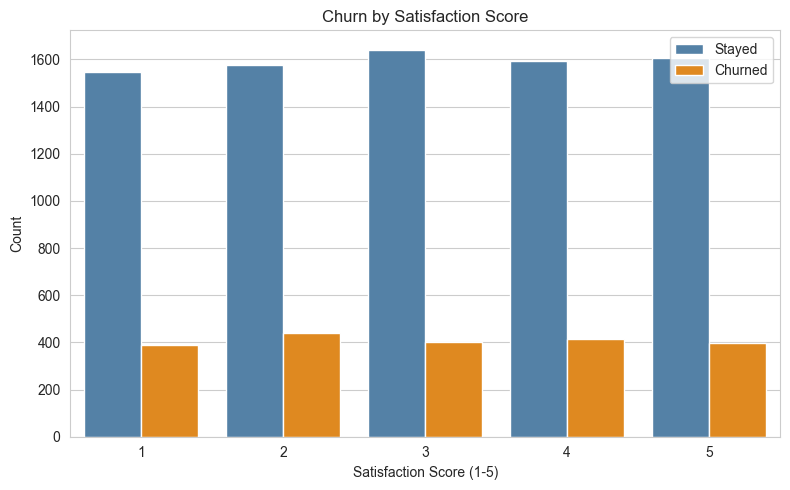

In [8]:
# The business logic: a customer who rates their experience low is signaling unhappiness.
# 3. Satisfaction score: Does a low satisfaction score predict churn?

# Churn rate by satisfaction score
plt.figure(figsize=(8, 5))
sns.countplot(x='Satisfaction Score', hue='Exited', data=df, palette=count_palette)
plt.title('Churn by Satisfaction Score')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_satisfaction.png')
plt.show()

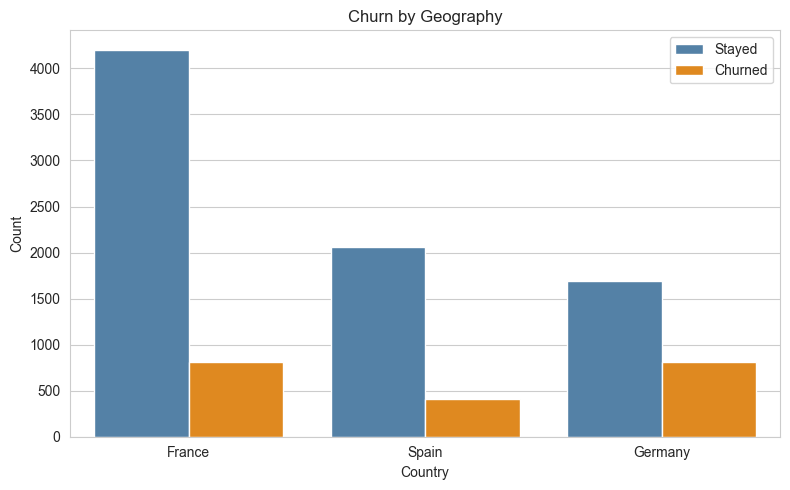

In [9]:
# The business logic: customers from certain regions may have different experiences and expectations,
# which could affect their likelihood to churn.
# 4. Geography: Are customers from certain regions more likely to churn?

# Churn rate by geography
plt.figure(figsize=(8, 5))
sns.countplot(x='Geography', hue='Exited', data=df, palette=count_palette)
plt.title('Churn by Geography')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_geography.png')
plt.show()

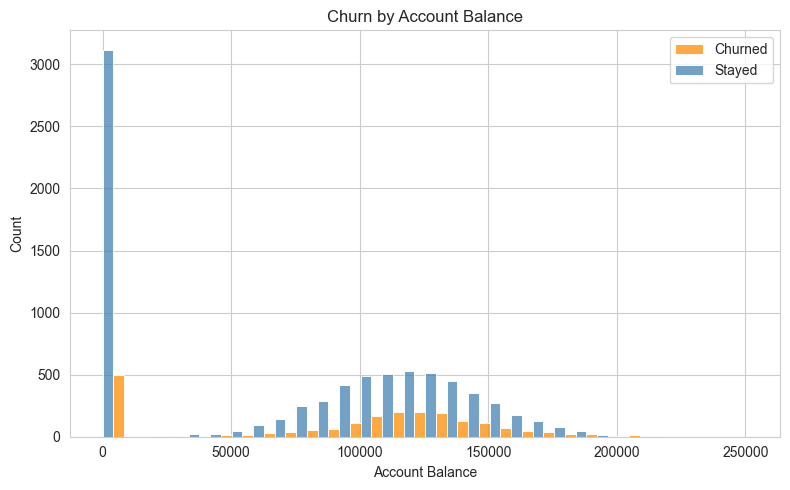

In [10]:
# The business logic: customers with higher balances have more at stake and may be more valuable to retain
# but they may also have more options and be more likely to switch to a competitor offering better returns.
# 5. Bank balance: Do customers with lower balances churn more?

# Churn rate by account balance
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Balance', hue='Exited', bins=30,
             palette=hist_palette, multiple='dodge',
             hue_order=[0, 1])
plt.title('Churn by Account Balance')
plt.xlabel('Account Balance')
plt.ylabel('Count')
plt.legend(labels=['Churned', 'Stayed'])
plt.tight_layout()
plt.savefig('churn_by_balance.png')
plt.show()

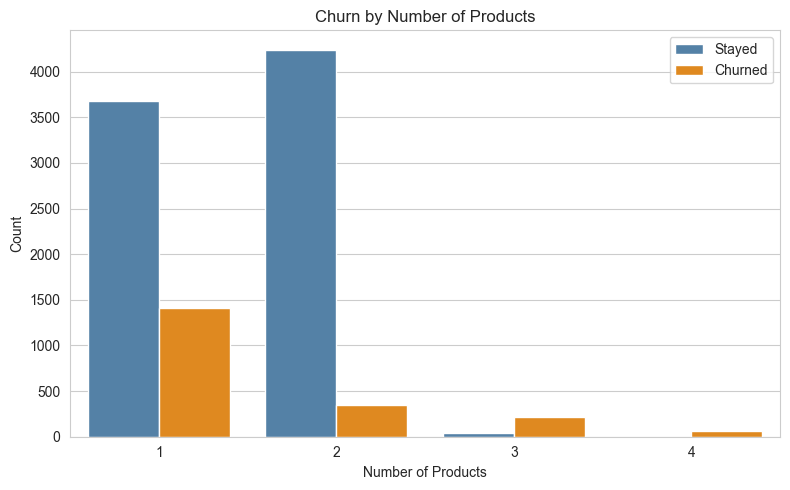

In [11]:
# The business logic: customers with more products may be more engaged and less likely to churn
# or they may be more likely to churn if they are dissatisfied with one of the products.
# 6. Number of products: Does having more products correlate with lower churn?

# Churn rate by number of products
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='NumOfProducts', hue='Exited', palette=count_palette)
plt.title('Churn by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_num_of_products.png')
plt.show()

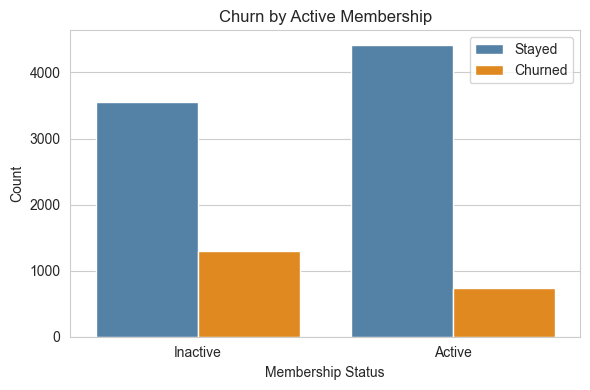

In [12]:
# The business logic: active members may be more engaged and less likely to churn,
# while inactive members may be more likely to churn.
# 7. Active membership: Does being an active member correlate with lower churn?

# Churn by active membership
plt.figure(figsize=(6, 4))
sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette=count_palette)
plt.title('Churn by Active Membership')
plt.xticks([0, 1], ['Inactive', 'Active'])
plt.xlabel('Membership Status')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_active_member.png')
plt.show()

In [13]:
# Data preprocessing
# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(df.shape)
print(df.columns.tolist())

(10000, 15)
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']


In [14]:
# Encode categorical variables.
# Label encode Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# One hot encode Geography and Card Type
df = pd.get_dummies(df, columns=['Geography', 'Card Type'], drop_first=True)

print(df.shape)
print(df.columns.tolist())

(10000, 18)
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned', 'Geography_Germany', 'Geography_Spain', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']


In [15]:
# Separate features(X) from the target variable(y)
X = df.drop(['Exited', 'Complain'], axis=1)
y = df['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 16)
Target shape: (10000,)


In [16]:
# Convert boolean columns to integers
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(X.dtypes)

CreditScore             int64
Gender                  int64
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Satisfaction Score      int64
Point Earned            int64
Geography_Germany       int64
Geography_Spain         int64
Card Type_GOLD          int64
Card Type_PLATINUM      int64
Card Type_SILVER        int64
dtype: object


In [17]:
# Split into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (8000, 16)
Test set: (2000, 16)


In [18]:
# Scale numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only, then transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [19]:
# Logistic Regression - Baseline Model

# Model building and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.813

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.62      0.21      0.32       408

    accuracy                           0.81      2000
   macro avg       0.73      0.59      0.60      2000
weighted avg       0.79      0.81      0.77      2000



In [20]:
# Logistic Regression Results
# Accuracy: 81.3% but recall for churned class is only 21%
# Model misses 79% of customers who actually churn
# Need to try more powerful models and handle class imbalance

In [21]:
print(df[['Complain', 'Exited']].value_counts())

Complain  Exited
0         0         7952
1         1         2034
          0           10
0         1            4
Name: count, dtype: int64


In [22]:
# Random Forest Classifier - More powerful model

# Model building and evaluation
from sklearn.ensemble import RandomForestClassifier

# Initialize and train
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.868

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1592
           1       0.82      0.46      0.58       408

    accuracy                           0.87      2000
   macro avg       0.85      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [23]:
# Random Forest Classifier Results
# Accuracy: 86.8%, recall for churned class improved to 46%
# Still missing 54% of churning customers

In [24]:
# Improvement: adjust classification threshold to improve recall

# Adjust classification threshold
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf_threshold = (y_pred_proba_rf >= 0.3).astype(int)

print("Random Forest Results - Adjusted Threshold (0.3)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_threshold))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_threshold))

Random Forest Results - Adjusted Threshold (0.3)
Accuracy: 0.8405

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1592
           1       0.60      0.67      0.63       408

    accuracy                           0.84      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.84      0.84      2000



In [25]:
# XGBoost Classifier - Another powerful model
from xgboost import XGBClassifier

# Initialize and train
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.828

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1592
           1       0.57      0.64      0.60       408

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83      0.83      2000



In [26]:
# XGBoost Results
# Accuracy: 82.8%, Recall (churned): 0.64, F1 (churned): 0.60
# Did not outperform Random Forest — final model: Random Forest (Threshold 0.3)
# Best recall (0.67) and F1 (0.63) for churned class

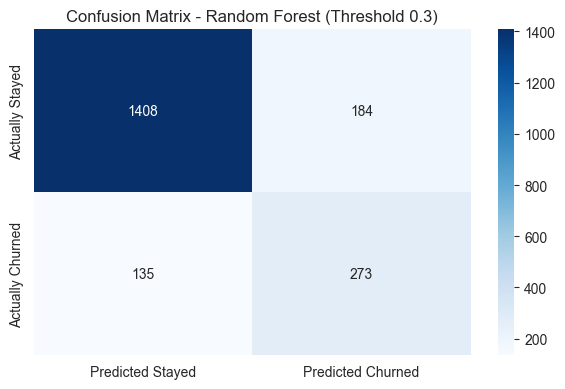

In [27]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_rf_threshold)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed', 'Predicted Churned'],
            yticklabels=['Actually Stayed', 'Actually Churned'])
plt.title('Confusion Matrix - Random Forest (Threshold 0.3)')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [28]:
# Confusion Matrix Results - Random Forest (Threshold 0.3)
# True Negatives: 1408 | False Positives: 184
# False Negatives: 135 | True Positives: 273
# Model catches 67% of churning customers (273/408)
# 135 churning customers missed - most costly error in business terms

C:\Users\USER\AppData\Local\Temp\ipykernel_34332\3768748776.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


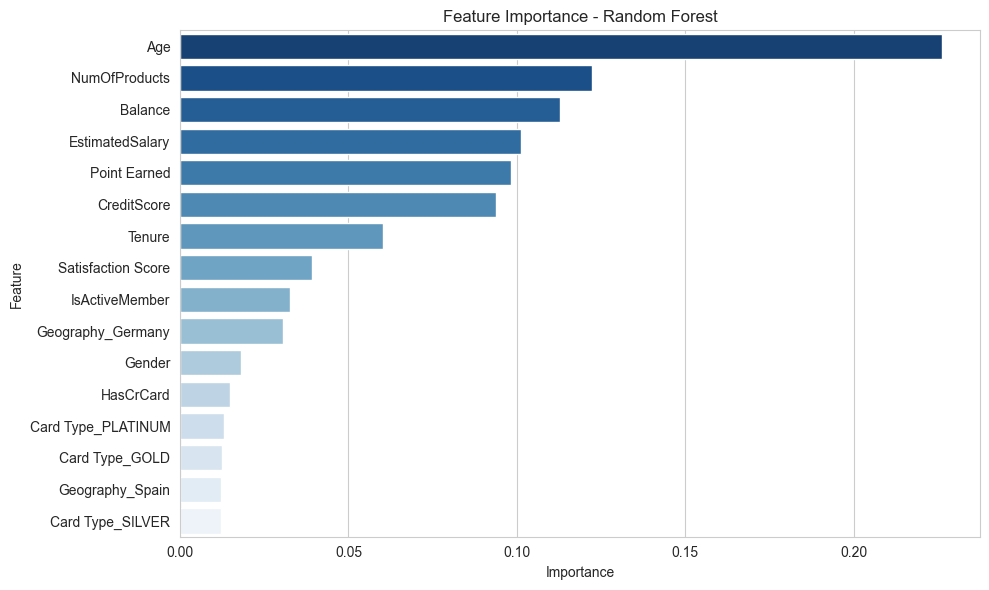

               Feature  Importance
2                  Age    0.226160
5        NumOfProducts    0.122279
4              Balance    0.112934
8      EstimatedSalary    0.101231
10        Point Earned    0.098177
0          CreditScore    0.093863
3               Tenure    0.060309
9   Satisfaction Score    0.039105
7       IsActiveMember    0.032788
11   Geography_Germany    0.030551
1               Gender    0.018166
6            HasCrCard    0.014731
14  Card Type_PLATINUM    0.013179
13      Card Type_GOLD    0.012323
12     Geography_Spain    0.012149
15    Card Type_SILVER    0.012056


In [29]:
# Feature importance
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance_df, palette='Blues_r')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(feature_importance_df)

In [30]:
# Feature Importance
# Top predictors: Age (22.6%), NumOfProducts (12.2%), Balance (11.3%)
# Weak predictors: HasCrCard, Card Type, Gender - minimal churn signal
# Business focus should be on age-targeted retention and product cross-selling

## Business Recommendations

### Model Summary
A Random Forest classifier was developed to predict customer churn, achieving **84.1% accuracy** and correctly identifying **67% of customers at risk of churning** (recall = 0.67). The model was trained on 8,000 customers and validated on 2,000 unseen records.

---

### Key Churn Drivers

| Driver | Importance | Finding |
|---|---|---|
| Age | 22.6% | Customers aged 40–70 churn disproportionately |
| Number of Products | 12.2% | 1 product = high volume risk; 3–4 products = near total churn |
| Account Balance | 11.3% | Mid-to-high balances (100K–150K) at greatest risk |
| Complaint Status | — | Removed from model due to near-perfect correlation with churn; 99.8% of complainants churned |

*Note: Complaint status was excluded from the predictive model as it is a simultaneous indicator of churn rather than a leading predictor. However it remains a critical operational signal.*

---

### Recommendations

**1. Implement a Complaints Resolution Programme**
Nearly every customer who raised a complaint subsequently churned. The bank should treat every complaint as a high-priority churn signal and implement a dedicated resolution team with a target response time of 24 hours. Proactive outreach to complainants before they escalate should be standard practice.

*Expected impact: Addressing complaints early could retain a significant portion of the 20% of customers currently lost to churn.*

---

**2. Launch Age-Targeted Retention Strategies**
Customers aged 40–70 churn at disproportionately high rates despite typically holding more assets. The bank should introduce premium relationship banking for this segment — dedicated relationship managers, tailored financial planning services, and loyalty rewards. This demographic represents the highest revenue-at-risk per customer.

*Expected impact: Retaining even 10% more of this segment would have an outsized impact on total deposits and revenue given their higher average balances.*

---

**3. Optimise Product Cross-Selling**
Customers with 2 products are the most loyal segment. The bank should prioritise moving single-product customers to 2 products through targeted cross-selling campaigns. Simultaneously, customers with 3 or 4 products should be reviewed — their near-total churn rate suggests product misalignment or poor fit rather than engagement.

*Expected impact: Increasing 1-product customers to 2 products would move them into the lowest churn segment, directly improving retention rates.*

---

**4. Protect High-Value Balance Customers**
Customers with balances between 100,000 and 150,000 represent a significant concentration of churn risk. These customers are valuable not only for their deposits but for their potential product uptake. The bank should introduce a high-value customer programme with enhanced benefits, personalised outreach, and priority service.

*Expected impact: Reducing churn in this balance segment would directly protect deposit levels and reduce revenue volatility.*

---

### Final Note
Retaining an existing customer costs significantly less than acquiring a new one. By deploying this model in production, the bank can proactively identify at-risk customers and intervene before they leave — shifting from reactive to predictive customer retention.